In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

data = {
    'Age': [25, 30, np.nan, 22, 30, 28, 400],
    'Salary': [50000, 60000, 55000, 45000, 60000, 52000, 80000],
    'Department': ['IT', 'HR', 'IT', 'Marketing', 'HR', 'IT', 'Finance'],
    'Performance': ['Good', 'Excellent', 'Average', 'Good', 'Excellent', 'Average', 'Good']
}
df = pd.DataFrame(data)

print("--- ข้อมูลเริ่มต้น ---")
display(df)

--- ข้อมูลเริ่มต้น ---


,Age,Salary,Department,Performance
0,25.0,50000,IT,Good
1,30.0,60000,HR,Excellent
2,NaN,55000,IT,Average
3,22.0,45000,Marketing,Good
4,30.0,60000,HR,Excellent
5,28.0,52000,IT,Average
6,400.0,80000,Finance,Good


In [21]:
print("\n--- LAB 1: Dataset Exploration ---")
print("1. Shape:", df.shape)
print("\n2. Data Types:\n", df.dtypes)
print("\n3. Summary Statistics:\n", df.describe())
print("\n4. Missing Values:\n", df.isnull().sum())
print("\n5. Duplicate Records:", df.duplicated().sum())


--- LAB 1: Dataset Exploration ---
1. Shape: (7, 4)

2. Data Types:
 Age            float64
Salary           int64
Department         str
Performance        str
dtype: object

3. Summary Statistics:
               Age        Salary
count    6.000000      7.000000
mean    89.166667  57428.571429
std    152.308131  11311.603819
min     22.000000  45000.000000
25%     25.750000  51000.000000
50%     29.000000  55000.000000
75%     30.000000  60000.000000
max    400.000000  80000.000000

4. Missing Values:
 Age            1
Salary         0
Department     0
Performance    0
dtype: int64

5. Duplicate Records: 1



--- LAB 2: Data Visualization ---


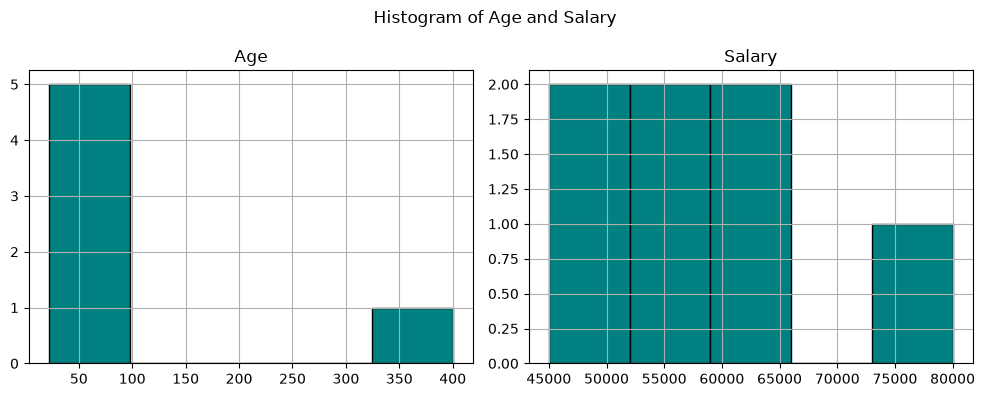

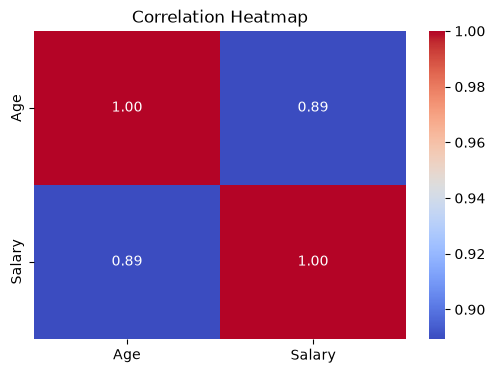

In [ ]:
print("\n--- LAB 2: Data Visualization ---")

df[['Age', 'Salary']].hist(figsize=(10, 4), bins=5, color='teal', edgecolor='black')
plt.suptitle("Histogram of Age and Salary")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [25]:
print("\n--- Part 3: Data Cleaning ---")

df.loc[df['Age'] > 120, 'Age'] = np.nan

print("เปรียบเทียบ Mean vs Median (ก่อนเติมค่าว่าง):")
print(f"Age - Mean: {df['Age'].mean():.2f}, Median: {df['Age'].median():.2f}")
print(f"Salary - Mean: {df['Salary'].mean():.2f}, Median: {df['Salary'].median():.2f}\n")

df['Age'] = df['Age'].fillna(df['Age'].median())

df = df.drop_duplicates()

df['Age'] = df['Age'].astype(int)

print("ทำความสะอาดข้อมูลเรียบร้อยแล้ว!")


--- Part 3: Data Cleaning ---
เปรียบเทียบ Mean vs Median (ก่อนเติมค่าว่าง):
Age - Mean: 26.83, Median: 28.00
Salary - Mean: 57000.00, Median: 53500.00

ทำความสะอาดข้อมูลเรียบร้อยแล้ว!


In [26]:
print("\n--- Part 4: Feature Engineering ---")

# 1. Label Encoding
le = LabelEncoder()
df['Performance_Encoded'] = le.fit_transform(df['Performance'])

# 2. One-Hot Encoding
df = pd.get_dummies(df, columns=['Department'], prefix='Dept')

print("ทำ Feature Engineering เรียบร้อยแล้ว")

print("\n--- ตารางข้อมูลสรุปผลสุดท้าย ---")
display(df)


--- Part 4: Feature Engineering ---
ทำ Feature Engineering เรียบร้อยแล้ว

--- ตารางข้อมูลสรุปผลสุดท้าย ---


,Age,Salary,Performance,Performance_Encoded,Dept_Finance,Dept_HR,Dept_IT,Dept_Marketing
0,25,50000,Good,2,False,False,True,False
1,30,60000,Excellent,1,False,True,False,False
2,28,55000,Average,0,False,False,True,False
3,22,45000,Good,2,False,False,False,True
5,28,52000,Average,0,False,False,True,False
6,28,80000,Good,2,True,False,False,False
